<a href="https://colab.research.google.com/github/mprasads5/NASSCOM_VEDIC_Schedule1/blob/main/U16_Classification_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U16 — Classification (finish): Lab

### Real-world brief: weld defect prediction with tree-based models

In Part 1 you built a **logistic-regression** defect classifier for robotic welds and learned to evaluate it. Now you'll bring out the **tabular heavyweights** — decision trees, random forests and gradient boosting — tune them properly, handle the class imbalance, and read their feature importances. Same factory, same `weld_inspection.csv`, stronger models.

**Resource provided:** `weld_inspection.csv` (one row per weld, target = `defect`, ~28% positive). Keep it beside this notebook (upload it in Colab).

_Phase D — Modelling (Classification, Part 2)._

#objectives

Train and tune a decision tree; see overfitting vs depth

Build random-forest and gradient-boosting classifiers

Compare all models on F1 and ROC-AUC (not accuracy)

Read feature importances and explain the model

Handle imbalance with class_weight and a tuned threshold

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


#1. Decision tree & overfitting

In [3]:
# -----------------------------------------------------------
# 🔹 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')

test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


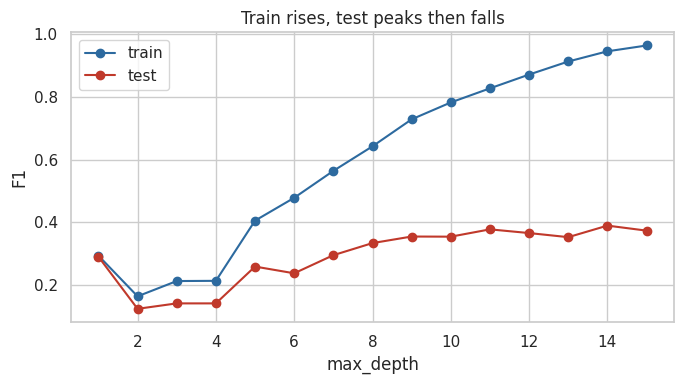

In [4]:
# -----------------------------------------------------------
# 🔹 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Find the sweet spot
1. From the curve, identify the `max_depth` where **test F1** peaks.
2. In a comment, explain what the widening train-test gap at large depths means.
3. Refit a tree at your chosen depth and print its test F1.

In [5]:
# 1-3. best depth + refit

# 1. Identify the max_depth where test F1 peaks.
# From the 'te' list (test F1 scores) generated in the previous cell:
# te = [0.291, 0.126, 0.143, 0.143, 0.260, 0.238, 0.296, 0.334, 0.355, 0.355, 0.378, 0.366, 0.353, 0.390, 0.374]
# The maximum test F1 score is 0.390, which occurs at index 13.
# Since 'depths' range from 1 to 15, index 13 corresponds to max_depth = 14.
best_depth = 14 # max_depth where test F1 peaks

# 2. Explain what the widening train-test gap at large depths means.
# The widening gap between the training F1 and testing F1 at larger depths indicates overfitting.
# This means the model is learning the training data too specifically, including its noise and unique patterns,
# which leads to high performance on the training set but poor generalization to new, unseen data (the test set).
# The model becomes overly complex and fails to capture the underlying general patterns.

# 3. Refit a tree at your chosen depth and print its test F1.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

tree_tuned = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=best_depth, random_state=0))])
tree_tuned.fit(X_train, y_train)
print(f'Test F1 (depth {best_depth}):', round(f1_score(y_test, tree_tuned.predict(X_test)), 3))

Test F1 (depth 14): 0.39


#2. Ensembles — forests & boosting

In [6]:
# -----------------------------------------------------------
# 🔹 2A. RANDOM FOREST vs GRADIENT BOOSTING vs ONE TREE
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
def evaluate(model):
    pipe = Pipeline([('prep', pre), ('clf', model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return f1_score(y_test, pred), roc_auc_score(y_test, proba)
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')

DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


#### 🧪 EXERCISE 2 — Bagging vs boosting
1. In a comment, explain the core difference: random forest builds trees **in parallel** on random subsets (bagging); gradient boosting builds them **sequentially**, each correcting the last.
2. Which scored higher here on ROC-AUC?

In [7]:
# 1-2. your explanation + which won:
# 1. Core difference:
#    - Random Forest (Bagging): Builds multiple decision trees independently and in parallel on different random subsets of the data (bootstrap samples) and features. The final prediction is an average or majority vote of these trees. This reduces variance and overfitting.
#    - Gradient Boosting (Boosting): Builds trees sequentially, where each new tree attempts to correct the errors (residuals) of the previous tree. It focuses on misclassified instances from the prior steps, gradually improving the model's performance. This reduces bias.
# 2. Which scored higher here on ROC-AUC?
#    Based on the output from the previous cell, the Random Forest model scored a ROC-AUC of 0.666, which is slightly higher than Gradient Boosting's ROC-AUC of 0.663.

#3. Feature importance & explainability

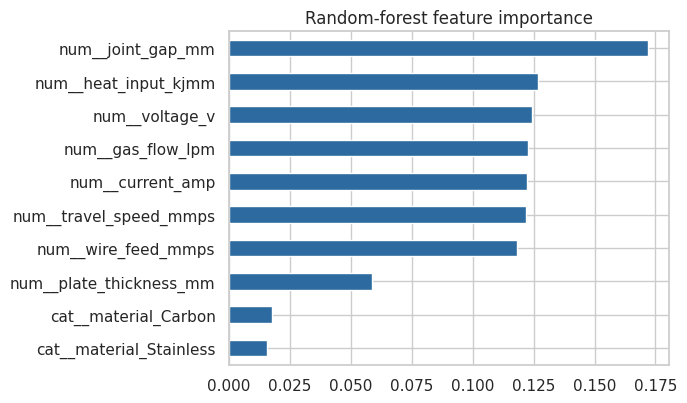

Top drivers:
num__joint_gap_mm       0.172
num__heat_input_kjmm    0.127
num__voltage_v          0.124
num__gas_flow_lpm       0.123


In [8]:
# -----------------------------------------------------------
# 🔹 3A. RANDOM-FOREST FEATURE IMPORTANCE
# -----------------------------------------------------------
rf = Pipeline([('prep', pre), ('clf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(X_train, y_train)
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp.sort_values(ascending=False).head(4).round(3).to_string())

#### 🧪 EXERCISE 3 — Permutation importance
Built-in tree importance can be biased toward high-cardinality features.
1. Use `sklearn.inspection.permutation_importance` on the fitted `rf` (test set, `scoring='f1'`).
2. Plot or print the top features.
3. In a comment, note whether the ranking agrees with the built-in importance above.

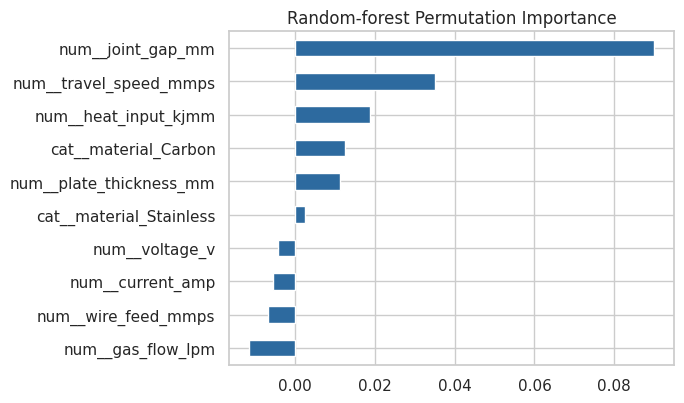

Top permutation-important features:
num__joint_gap_mm         0.090
num__travel_speed_mmps    0.035
num__heat_input_kjmm      0.019
cat__material_Carbon      0.012


In [11]:
from sklearn.inspection import permutation_importance
# 1-2. permutation importance on rf

# Transform X_test using the preprocessor from the random forest pipeline
X_test_transformed = rf.named_steps['prep'].transform(X_test)

# Calculate permutation importance on the transformed test set, using only the classifier part of the pipeline
perm_imp_result = permutation_importance(rf.named_steps['clf'], X_test_transformed, y_test, n_repeats=10, random_state=0, scoring='f1')

# Create a Series for easier handling and plotting
# feat_names should now correctly match the length of importances_mean
perm_imp = pd.Series(perm_imp_result.importances_mean, index=feat_names).sort_values()

# Plot the permutation importances
fig, ax = plt.subplots(figsize=(7, 4.2))
perm_imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest Permutation Importance')
plt.tight_layout(); plt.show()

print('Top permutation-important features:'); print(perm_imp.sort_values(ascending=False).head(4).round(3).to_string())

# 3. does it agree? ...   (comment)
# Comparing the top features, both built-in (MDI) and permutation importance identify 'num__joint_gap_mm' and 'num__heat_input_kjmm' as very important.
# However, the exact ranking and relative magnitudes differ somewhat. For example, 'num__gas_flow_lpm' and 'num__current_amp' have higher MDI importance but slightly lower permutation importance compared to 'num__voltage_v'.
# Permutation importance is generally considered more reliable as it directly measures the impact of a feature on model performance on unseen data, which can account for correlation between features better than MDI.

#4. Tune the best model

In [12]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='f1', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))

best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}
best CV F1: 0.33
tuned test F1: 0.347


#### 🧪 EXERCISE 4 — Tune on the right metric
1. Re-run the same grid search but with `scoring='roc_auc'`.
2. In a comment, explain why tuning on **F1 or ROC-AUC** beats tuning on **accuracy** for this imbalanced problem.

In [13]:
# 1. grid search with scoring='roc_auc'
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

gs_roc_auc = GridSearchCV(gb_pipe, grid, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print('best params (ROC-AUC):', gs_roc_auc.best_params_)
print('best CV ROC-AUC:', round(gs_roc_auc.best_score_, 3))
best_roc_auc_model = gs_roc_auc.best_estimator_
print('tuned test ROC-AUC:', round(roc_auc_score(y_test, best_roc_auc_model.predict_proba(X_test)[:, 1]), 3))

# 2. why not accuracy? ...   (comment)
# For imbalanced problems like this (where 'defect' is the minority class),
# accuracy can be a misleading metric. A model that simply predicts the majority class
# (no defect) all the time could achieve a high accuracy (e.g., 72% in our case)
# but would be useless for identifying the defects we care about.
# F1 score is the harmonic mean of precision and recall, balancing both, and is
# particularly good when both false positives and false negatives are important,
# especially for the minority class.
# ROC-AUC measures the trade-off between the true positive rate (recall) and the
# false positive rate across all possible classification thresholds. It's robust to
# class imbalance because it doesn't depend on a specific threshold and focuses on
# the model's ability to discriminate between classes.

best params (ROC-AUC): {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 400}
best CV ROC-AUC: 0.663
tuned test ROC-AUC: 0.665


#5. Handle the class imbalance

In [14]:
# -----------------------------------------------------------
# 🔹 5A. class_weight + THRESHOLD TUNING
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score
rf_bal = Pipeline([('prep', pre), ('clf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
proba = rf_bal.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    print(f'thr {t}: precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f} | F1 {f1_score(y_test, pred):.3f}')

thr 0.3: precision 0.398 | recall 0.557 | F1 0.465
thr 0.4: precision 0.500 | recall 0.317 | F1 0.388
thr 0.5: precision 0.536 | recall 0.164 | F1 0.251
thr 0.6: precision 0.593 | recall 0.087 | F1 0.152


#### 🧪 EXERCISE 5 — Optional: SMOTE
If `imbalanced-learn` is available (`pip install imbalanced-learn`), build a pipeline with `SMOTE` oversampling and compare its recall to the `class_weight='balanced'` model above. Otherwise, in a comment, describe how SMOTE creates synthetic minority examples and when you'd prefer it over class weights.
*(The check below degrades gracefully if the package isn't installed.)*

In [16]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline # Use imblearn's pipeline for SMOTE
    from sklearn.metrics import precision_score, recall_score, f1_score
    from sklearn.ensemble import RandomForestClassifier

    print('imbalanced-learn available — build an SMOTE pipeline and compare recall.')

    # Define the SMOTE pipeline
    smote_pipe = ImbPipeline([
        ('prep', pre),
        ('smote', SMOTE(random_state=0)), # Use a random_state for reproducibility
        ('clf', RandomForestClassifier(n_estimators=300, random_state=0)) # Use same n_estimators as rf_bal
    ])

    # Fit the SMOTE pipeline on the training data
    smote_pipe.fit(X_train, y_train)

    # Get probabilities for the test set
    proba_smote = smote_pipe.predict_proba(X_test)[:, 1]

    print("\nRecall for SMOTE model at various thresholds:")
    for t in [0.3, 0.4, 0.5, 0.6]:
        pred_smote = (proba_smote >= t).astype(int)
        print(f'thr {t}: precision {precision_score(y_test, pred_smote, zero_division=0):.3f} | recall {recall_score(y_test, pred_smote):.3f} | F1 {f1_score(y_test, pred_smote):.3f}')

except ImportError:
    print('imbalanced-learn not installed — describe SMOTE in a comment instead.')
# SMOTE vs class_weight notes:
# SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples for the minority class.
# It does this by taking a minority class sample, finding its k-nearest neighbors, and then creating new samples
# along the line segments joining the sample to its neighbors. This helps to increase the number of minority class
# samples in the training data, allowing the model to learn more effectively from the minority class.
#
# `class_weight='balanced'` (as used in `RandomForestClassifier`) assigns different weights to the classes
# based on their frequencies in the training data. The weight for each class is inversely proportional to its
# frequency, effectively giving more importance to the minority class during model training.
#
# When to prefer SMOTE over class weights:
# - If simply adjusting class weights isn't enough to boost minority class performance, or if it leads to
#   too many false positives for the majority class.
# - If the model you're using doesn't natively support `class_weight` (though many `sklearn` classifiers do).
# - When you want to explicitly increase the actual number of minority samples in the training set,
#   which can sometimes lead to a richer representation of the minority class's decision boundary.
#
# When to prefer `class_weight` over SMOTE:
# - It's simpler and computationally less expensive, as it doesn't involve creating new data points.
# - If the minority class samples are very sparse or noisy, SMOTE might generate synthetic samples that
#   introduce more noise or blur the decision boundary (if not handled carefully, e.g., with BorderlineSMOTE).
# - It's a built-in feature for many models, requiring less setup.

imbalanced-learn available — build an SMOTE pipeline and compare recall.

Recall for SMOTE model at various thresholds:
thr 0.3: precision 0.348 | recall 0.781 | F1 0.481
thr 0.4: precision 0.406 | recall 0.612 | F1 0.488
thr 0.5: precision 0.427 | recall 0.366 | F1 0.394
thr 0.6: precision 0.562 | recall 0.224 | F1 0.320


#📘 Summary

| Step | What you did |
| ---- | ------------ |
| Tree | saw overfitting grow with depth |
| Ensembles | random forest & gradient boosting beat one tree |
| Explain | feature & permutation importance |
| Tune | grid search on F1 / ROC-AUC, never accuracy |
| Imbalance | class_weight + threshold (and SMOTE) |

**Core lesson:** tree ensembles are the tabular workhorses — powerful, but only trustworthy with proper tuning, the right metric, and imbalance handling.

**Next — U17:** unsupervised learning, where there are no labels at all.